# 07 · Generación de imágenes de gatos desde checkpoint (`cats_vp.yaml`)

Este notebook permite **generar muestras de imágenes (gatos)** a partir de un modelo de score
`ScoreUNet` (Fase 2) entrenado con la configuración **`config/cats_vp.yaml`** (o cualquier checkpoint compatible).

### Objetivos y estructura:
1. **Configuración y Checkpoint**: Cargar la receta desde `config/cats_vp.yaml` e inspeccionar la metadata del checkpoint.
2. **Generación desde ruido (Prueba 3 - Notebook 06)**: Partir de $x_T \sim \mathcal{N}(0, I)$ e integrar el proceso reverso con **Predictor-Corrector (`pc`)**.
3. **Estudio de Samplers del Eje 2**: Comparar los 4 samplers del reverso (`euler`, `pf_ode`, `heun`, `pc`) manteniendo el **mismo score $s_\theta(x,t)$ y la misma semilla de ruido**.
4. **Visualización de Trayectorias**: Observar la evolución temporal del proceso reverso $x_t \to x_0$ a lo largo de la integración.
5. **Análisis de Overfitting (Vecinos Más Cercanos)**: Buscar las imágenes del dataset de entrenamiento con menor distancia MSE a las muestras generadas para determinar si el modelo memorizó o generalizó la distribución.

In [15]:
# --- Setup: bootstrap de sys.path + imports + helpers de visualización ---
import sys
import pathlib
import yaml

_here = pathlib.Path.cwd()
_root = None
for _cand in (_here, *_here.parents):
    if (_cand / "src" / "diffusion").is_dir():
        _root = _cand
        break
if _root is None:
    raise RuntimeError(f"No encontré src/diffusion subiendo desde {_here}")
_src = str((_root / "src").resolve())
if _src not in sys.path:
    sys.path.insert(0, _src)

import numpy as np
import torch
import matplotlib.pyplot as plt

from diffusion.samplers import generate_from_checkpoint, available_samplers, make_sampler
from diffusion.training import load_checkpoint
from diffusion.sde import make_sde
from diffusion.models import make_model, EpsilonScoreWrapper
from diffusion.data_generation import infinite_batches

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})


def denorm(t):
    """(B,3,H,W) en [-1,1] -> (B,H,W,3) numpy en [0,1]."""
    x = (t.detach() * 0.5 + 0.5).clamp(0.0, 1.0)
    return x.permute(0, 2, 3, 1).cpu().numpy()


def show_grid(imgs, titles=None, suptitle=None, cols=4):
    """Muestra un lote de imágenes (B,3,H,W) o (B,H,W,3) en grilla."""
    arr = denorm(imgs) if torch.is_tensor(imgs) else imgs
    n = arr.shape[0]
    cols = min(cols, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(2.8 * cols, 3.0 * rows))
    axes_flat = np.atleast_1d(axes).flat
    for i in range(rows * cols):
        if i < n:
            axes_flat[i].imshow(arr[i])
            axes_flat[i].axis("off")
            if titles is not None and i < len(titles):
                axes_flat[i].set_title(titles[i], fontsize=9)
        else:
            axes_flat[i].axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=12, y=1.02)
    fig.tight_layout()
    plt.show()


print("Paquete en:", _root)
print("PyTorch versión:", torch.__version__)
print("Samplers disponibles:", available_samplers())

Paquete en: /home/abravo/estocastico/diffusion-models
PyTorch versión: 2.12.0+cu130
Samplers disponibles: ['euler', 'heun', 'pc', 'pf_ode']


## 1. Localización del Checkpoint e Inspección de Metadata

Leemos `config/cats_vp.yaml` para obtener la ruta objetivo del checkpoint (`out.checkpoint`).
Si el checkpoint entrenado en GPU (`cats_vp.pt`) aún no está presente en la ruta local, usamos como respaldo el checkpoint `models/phase_2/cats_prueba_vp.pt` generado en la prueba de integración de Fase 2.

In [ ]:
# --- Cargar configuración y verificar checkpoint ---
config_path = _root / "config" / "cats_vp.yaml"

if config_path.exists():
    with open(config_path, "r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f)
    target_ckpt = pathlib.Path(cfg["out"]["checkpoint"])
    print(f"Configuración cargada desde: {config_path}")
    print(f"Ruta objetivo del checkpoint (YAML): {target_ckpt}")
else:
    target_ckpt = pathlib.Path("/mnt/data/abravo/diffusion-models/phase_2/cats_vp.pt")
    print(f"No se encontró {config_path}, usando ruta por defecto: {target_ckpt}")

# Búsqueda de candidato de checkpoint existente
candidate_paths = [
    target_ckpt,
    _root / "models" / "phase_2" / "cats_vp.pt",
]

CKPT_PATH = None
for cand in candidate_paths:
    if cand.exists():
        CKPT_PATH = cand
        break

if CKPT_PATH is None:
    raise FileNotFoundError(
        f"No se encontró ningún checkpoint en las rutas probadas: {[str(p) for p in candidate_paths]}"
    )

print(f"\nUsing checkpoint: {CKPT_PATH}")

# Cargar metadata sin instanciar pesos
state_dict, meta = load_checkpoint(CKPT_PATH, map_location="cpu")

print("\n--- Metadata del Checkpoint ---")
print("SDE          :", meta.get("sde_name"), f"(data_dim={meta.get('data_dim')})")
model_recipe = meta.get("model", {})
print("Modelo       :", model_recipe.get("name"), f"kwargs={model_recipe.get('kwargs')}")
print("Parametrización:", model_recipe.get("score_parametrization", "score directo"))

if "history" in meta:
    hist = meta["history"]
    print(f"Historial    : {len(hist)} registros de loss (Loss inicial: {hist[0]:.4f} -> final: {hist[-1]:.4f})")

No se encontró /home/abravo/estocastico/diffusion-models/config/cats_vp_30000.yaml, usando ruta por defecto: /mnt/data/abravo/diffusion-models/phase_3/cats_vp_30000.pt

Using checkpoint: /mnt/data/abravo/diffusion-models/phase_3/cats_vp_30000.pt

--- Metadata del Checkpoint ---
SDE          : vp (data_dim=(3, 64, 64))
Modelo       : unet kwargs={'in_channels': 3, 'image_size': 64, 'base_channels': 128, 'channel_mults': [1, 2, 2, 2], 'num_res_blocks': 2, 'embed_dim': 256, 'time_embed_dim': 512, 'attn_resolutions': [16, 8], 'groups': 32, 'time_scale': 1000.0}
Parametrización: epsilon
Historial    : 30000 registros de loss (Loss inicial: 1.1495 -> final: 0.0235)


## 2. Generación desde ruido con Predictor-Corrector (`pc`)

Invocamos `generate_from_checkpoint` para partir de $x_T \sim \mathcal{N}(0, I)$ e integrar el reverso con el sampler Predictor-Corrector (`pc`).
Las correcciones de Langevin del predictor-corrector ayudan a mantener la trayectoria cerca de la variedad de datos.

Generando 4 muestras con sampler 'pc' (100 pasos)...
Tensor generado: shape=(4, 3, 64, 64), dtype=torch.float32
Rango de valores: min=-1.234, max=1.103
¿Valores finitos (sin NaNs/Infs)?: True


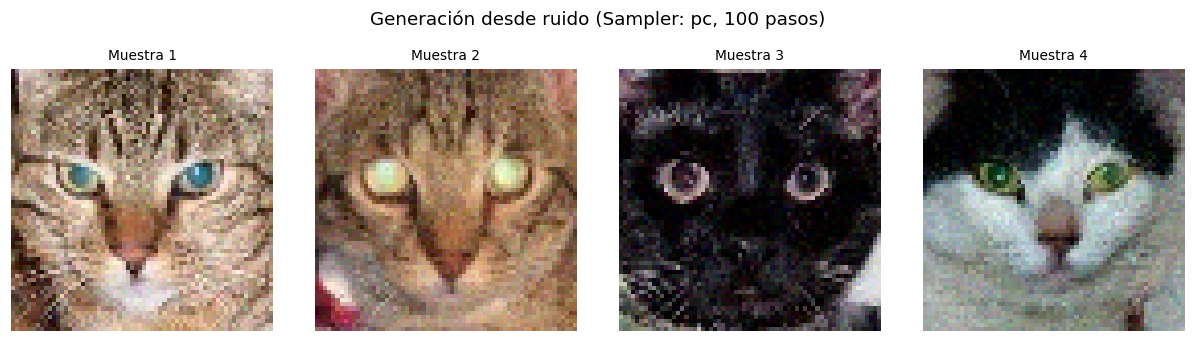

In [17]:
# --- Generación desde ruido usando Predictor-Corrector (en GPU) ---
N_SAMPLES = 4
N_STEPS = 100
SAMPLER_NAME = "pc"

print(f"Generando {N_SAMPLES} muestras con sampler '{SAMPLER_NAME}' ({N_STEPS} pasos)...")

samples_pc = generate_from_checkpoint(
    CKPT_PATH,
    sampler_name=SAMPLER_NAME,
    n_samples=N_SAMPLES,
    n_steps=N_STEPS,
    seed=SEED,
    device="cuda",     # <-- corre en GPU (mueve la red + samplea en cuda). map_location NO alcanzaba.
).cpu()                # <-- a CPU para graficar/analizar sin líos de device

print(f"Tensor generado: shape={tuple(samples_pc.shape)}, dtype={samples_pc.dtype}")
print(f"Rango de valores: min={float(samples_pc.min()):.3f}, max={float(samples_pc.max()):.3f}")
print("¿Valores finitos (sin NaNs/Infs)?:", bool(torch.isfinite(samples_pc).all()))

show_grid(
    samples_pc,
    titles=[f"Muestra {i+1}" for i in range(N_SAMPLES)],
    suptitle=f"Generación desde ruido (Sampler: {SAMPLER_NAME}, {N_STEPS} pasos)",
    cols=4
)

## 3. Estudio de Ablación de Samplers (Eje 2)

Manteniendo **fija la red de score $s_\theta(x,t)$** y la **misma semilla de ruido inicial $x_T$**, comparamos el comportamiento de los distintos samplers del reverso:
1. **`euler`**: Euler–Maruyama (estocástico).
2. **`pf_ode`**: Probability-Flow ODE (Euler determinístico).
3. **`heun`**: Predictor-Corrector de 2º orden para ODE (EDM).
4. **`pc`**: Predictor-Corrector (SDE + corrección Langevin).

Generando muestras con sampler 'euler' (100 pasos)...


Generando muestras con sampler 'pf_ode' (100 pasos)...
Generando muestras con sampler 'heun' (100 pasos)...
Generando muestras con sampler 'pc' (100 pasos)...


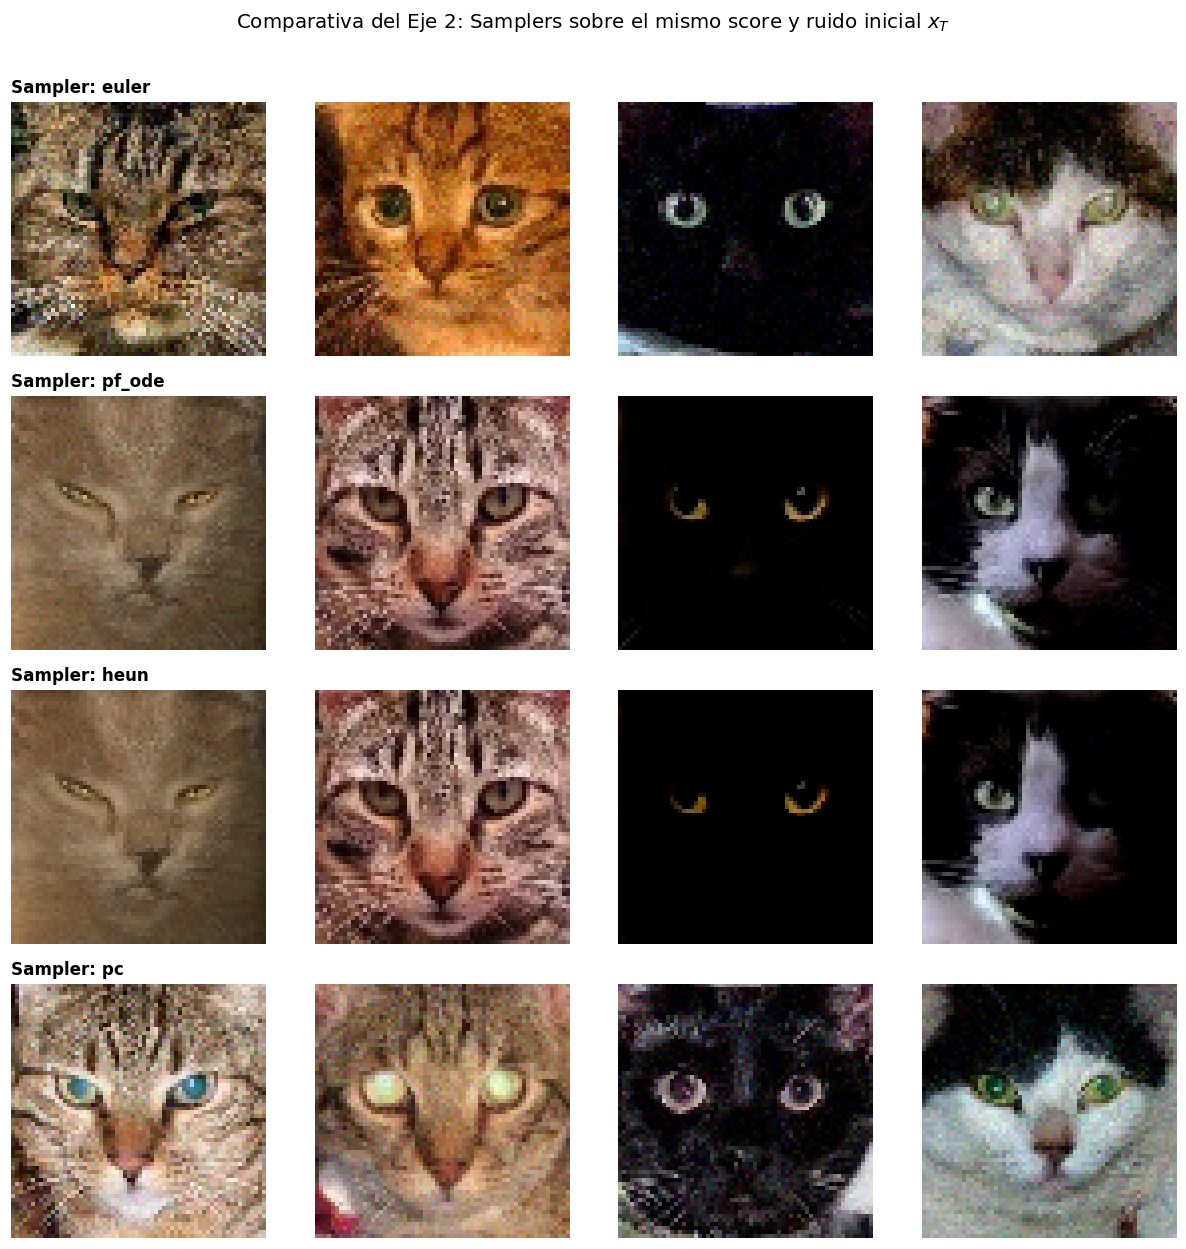

In [18]:
# --- Comparación de los 4 samplers con el mismo ruido inicial (en GPU) ---
samplers_to_compare = ["euler", "pf_ode", "heun", "pc"]
num_samples_cmp = 4
N_STEPS_CMP = 100

sampler_results = {}

for s_name in samplers_to_compare:
    print(f"Generando muestras con sampler '{s_name}' ({N_STEPS_CMP} pasos)...")
    samples = generate_from_checkpoint(
        CKPT_PATH,
        sampler_name=s_name,
        n_samples=num_samples_cmp,
        n_steps=N_STEPS_CMP,
        seed=SEED,          # misma semilla -> mismo x_T inicial
        device="cuda",      # <-- en GPU
    ).cpu()
    sampler_results[s_name] = samples

# Visualización comparativa por sampler (filas = samplers, columnas = muestras)
fig, axes = plt.subplots(len(samplers_to_compare), num_samples_cmp, figsize=(2.8 * num_samples_cmp, 2.8 * len(samplers_to_compare)))

for row_idx, s_name in enumerate(samplers_to_compare):
    arr = denorm(sampler_results[s_name])
    for col_idx in range(num_samples_cmp):
        ax = axes[row_idx, col_idx]
        ax.imshow(arr[col_idx])
        ax.axis("off")
        if col_idx == 0:
            ax.set_title(f"Sampler: {s_name}", fontsize=11, fontweight="bold", loc="left")

fig.suptitle("Comparativa del Eje 2: Samplers sobre el mismo score y ruido inicial $x_T$", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 4. Visualización de la Trayectoria de Integración Reversa ($x_t \to x_0$)

Capturamos la trayectoria completa de la integración usando `save_trajectory=True` para observar cómo evolucionar la imagen desde el ruido puro ($t=1$) hasta la muestra final ($t=0$).

Trayectoria capturada: shape=(501, 1, 3, 64, 64)


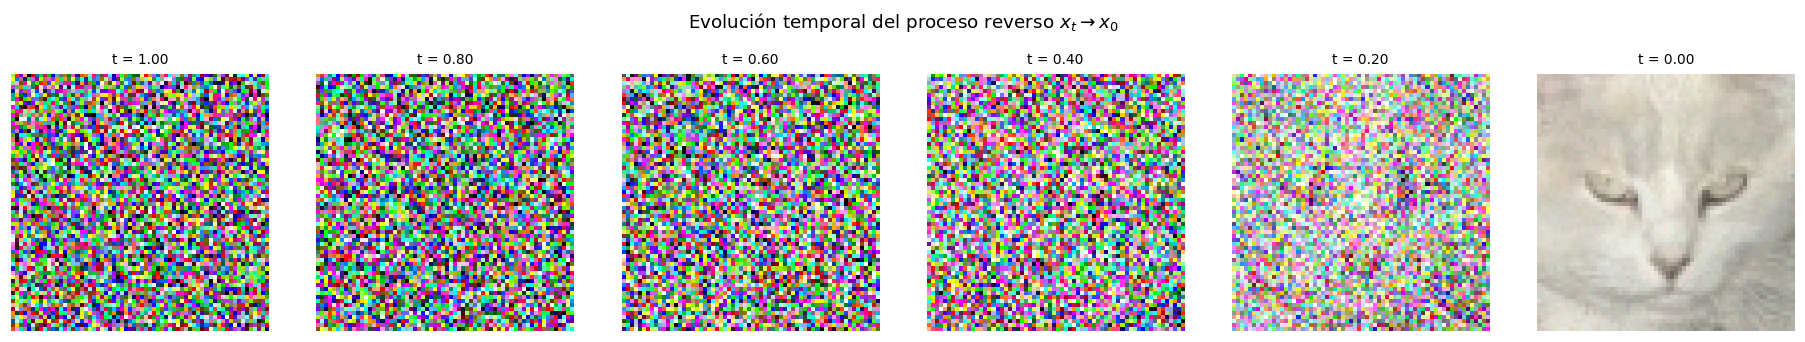

In [19]:
# --- Captura y visualización de la trayectoria reverso (en GPU) ---
N_STEPS_TRAJ = 500   # pasos de INTEGRACIÓN (van al constructor del sampler, NO a sample())

state_dict, meta = load_checkpoint(CKPT_PATH, map_location="cpu")
sde = make_sde(meta["sde_name"], data_dim=meta["data_dim"])
raw_net = make_model(meta["model"]["name"], **dict(meta["model"]["kwargs"]))

if meta["model"].get("score_parametrization") == "epsilon":
    net = EpsilonScoreWrapper(raw_net, lambda x, t: sde.marginal_prob(x, t)[1])
else:
    net = raw_net

net.load_state_dict(state_dict)
net.eval().to("cuda")                       # red a GPU

# n_steps va al CONSTRUCTOR del sampler (sample() no recibe n_steps):
sampler = make_sampler("pc", sde=sde, score_fn=net, n_steps=N_STEPS_TRAJ)

g = torch.Generator(device="cuda").manual_seed(SEED)                       # generator en cuda
x_T = sde.prior_sampling(shape=(1, *sde.data_shape), generator=g, device="cuda")

# n_samples=1 (coincide con el batch de init), NO N_STEPS_TRAJ:
x_0, trajectory = sampler.sample(n_samples=1, init=x_T, return_trajectory=True, generator=g)

print(f"Trayectoria capturada: shape={tuple(trajectory.shape)}")  # (N_STEPS_TRAJ+1, 1, 3, H, W)

indices = np.linspace(0, len(trajectory) - 1, 6, dtype=int)
traj_samples = trajectory[indices, 0]       # (6, 3, H, W); denorm hace .cpu()

t_values = np.linspace(sde.T, 1e-4, len(trajectory))[indices]
titles = [f"t = {t:.2f}" for t in t_values]

show_grid(
    traj_samples,
    titles=titles,
    suptitle=r"Evolución temporal del proceso reverso $x_t \to x_0$",
    cols=6
)

## 5. Análisis de Overfitting: Búsqueda de Vecinos Más Cercanos en el Dataset

Para determinar si el modelo **memorizó** especímenes concretos del entrenamiento (overfitting) o si **aprendió la distribución subyacente** (generalización):
- Cargamos un conjunto de imágenes reales del dataset de entrenamiento.
- Calculamos la distancia Mean Squared Error (MSE) en espacio de píxeles entre cada muestra generada $x_{\text{gen}}$ y todas las imágenes del dataset $x_{\text{real}}$.
- Mostramos para cada muestra generada sus $K$ **vecinos más cercanos (Nearest Neighbors)** junto con su distancia MSE.

> **Interpretación:**
> - **Si MSE $\approx 0$ e imagen idéntica:** El modelo memorizó esa imagen exacta del entrenamiento.
> - **Si MSE $> 0$ y difiere en rasgos:** El modelo generalizó y produjo una nueva instancia que comparte características de la variedad de gatos pero no copia a ningún gato del dataset.

Cargando dataset desde: /home/abravo/estocastico/diffusion-models/data/cats-v1


Comparando contra 18608 imágenes (9304 originales + 9304 espejadas), 64x64


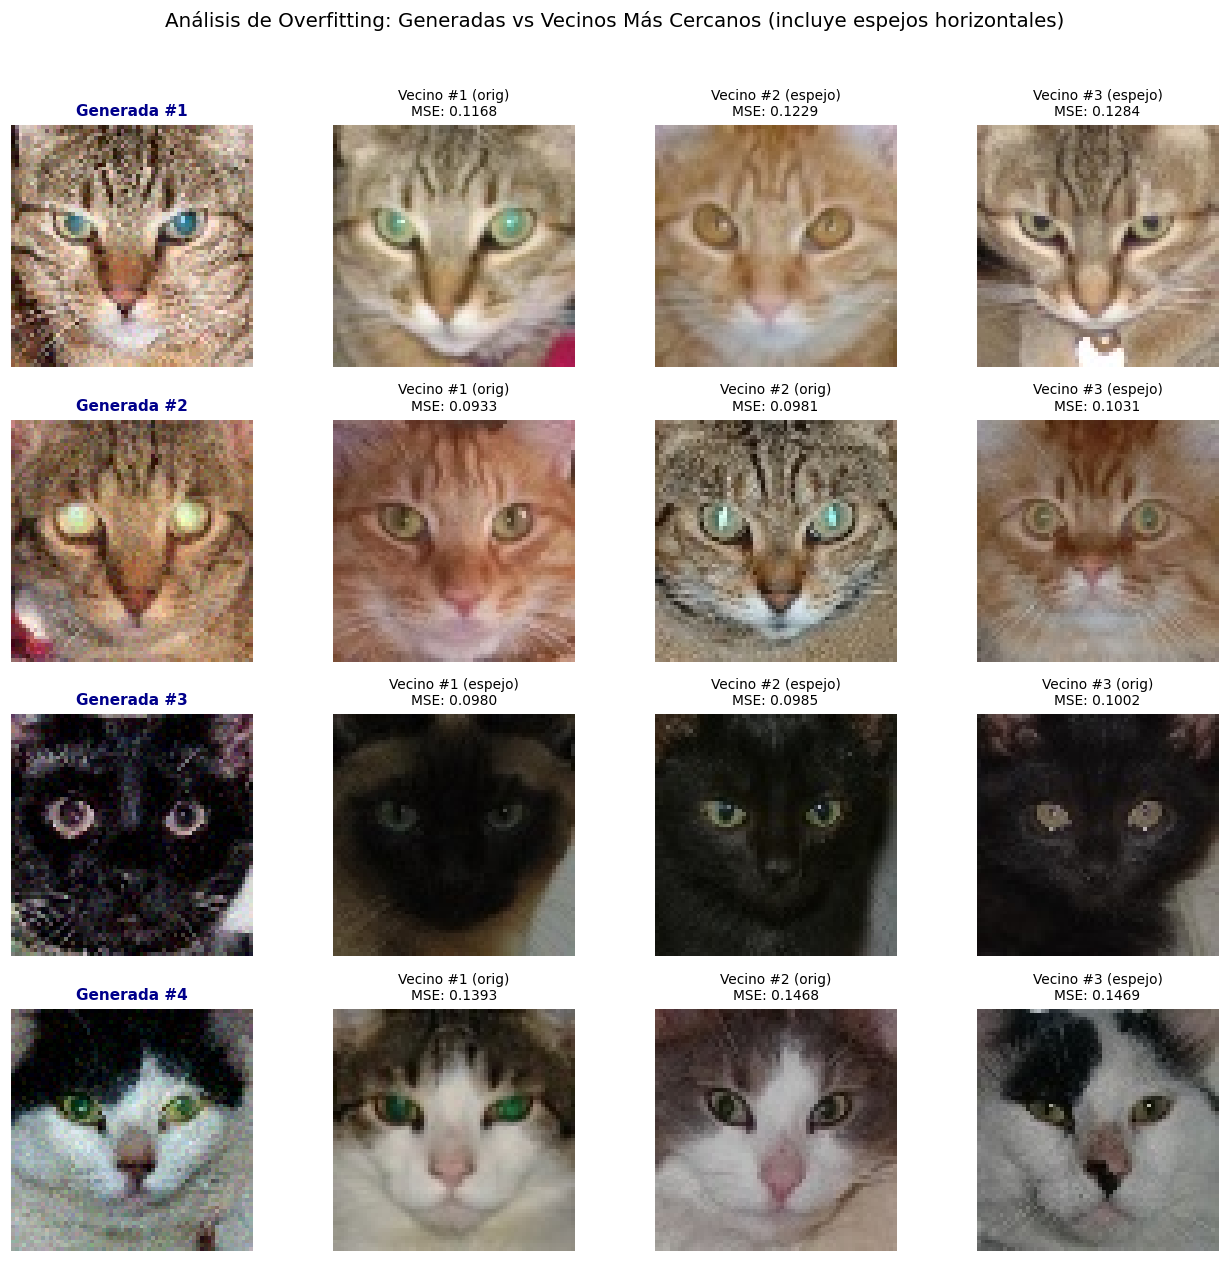

In [20]:
# --- 5. Búsqueda de vecinos más cercanos en el dataset (incluye espejos horizontales) ---
# Para detectar memorización comparamos cada muestra generada contra CADA gato del dataset en
# AMBAS orientaciones (original + espejo horizontal). El entrenamiento usa flip horizontal, así que
# un gato "memorizado pero dado vuelta" solo aparece si consideramos también el espejo.
data_dir_candidates = [
    _root / "data" / "cats-v1",
]

DATA_DIR = None
for d_cand in data_dir_candidates:
    if d_cand.exists() and any(d_cand.iterdir()):
        DATA_DIR = d_cand
        break

if DATA_DIR is None:
    print("No se encontró carpeta de dataset de imágenes en data/. Salteando la búsqueda de vecinos.")
else:
    print(f"Cargando dataset desde: {DATA_DIR}")
    img_size = meta["model"]["kwargs"].get("image_size", sde.data_shape[-1])

    # batch_size no puede superar la cantidad de imágenes (infinite_batches hace fail-fast):
    _exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    n_imgs = sum(1 for p in DATA_DIR.rglob("*") if p.suffix.lower() in _exts)

    # augment=False -> orientación canónica y determinística; el espejo lo agregamos a mano.
    dataset_iter = infinite_batches(
        DATA_DIR, batch_size=n_imgs, image_size=img_size,
        augment=False, shuffle=False, num_workers=0, seed=SEED
    )
    X_dataset = next(dataset_iter)                    # (N, 3, H, W) en CPU
    X_flip = torch.flip(X_dataset, dims=[-1])         # espejo horizontal (última dim = ancho)
    X_all = torch.cat([X_dataset, X_flip], dim=0)     # (2N, 3, H, W): [originales | espejadas]
    N = X_dataset.shape[0]
    print(f"Comparando contra {X_all.shape[0]} imágenes ({N} originales + {N} espejadas), {img_size}x{img_size}")

    # Búsqueda de Top-K vecinos para las muestras generadas en la Sección 2.
    samples_cpu = samples_pc.cpu()  # asegurar CPU (X_all está en CPU)
    N_gen = samples_cpu.shape[0]
    K_NEIGHBORS = 3

    fig, axes = plt.subplots(
        N_gen, K_NEIGHBORS + 1,
        figsize=(3.0 * (K_NEIGHBORS + 1), 2.8 * N_gen)
    )
    if N_gen == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(N_gen):
        gen_img = samples_cpu[i:i+1]  # (1, 3, H, W) en CPU
        # Distancia MSE en píxeles contra originales Y espejos: promediar sobre (C, H, W)
        mse_distances = torch.mean((X_all - gen_img) ** 2, dim=(1, 2, 3)).cpu().numpy()  # (2N,)

        # Índices con menor MSE (sobre el set duplicado original+espejo)
        top_k_indices = np.argsort(mse_distances)[:K_NEIGHBORS]

        # Columna 0: Imagen generada
        axes[i, 0].imshow(denorm(gen_img)[0])
        axes[i, 0].set_title(f"Generada #{i+1}", fontsize=10, fontweight="bold", color="darkblue")
        axes[i, 0].axis("off")

        # Columnas 1..K: Vecinos más cercanos (con etiqueta de orientación)
        for k_idx, neighbor_idx in enumerate(top_k_indices):
            etiqueta = "espejo" if neighbor_idx >= N else "orig"   # idx >= N -> vino de X_flip
            neighbor_img = X_all[neighbor_idx:neighbor_idx + 1]
            dist = mse_distances[neighbor_idx]

            axes[i, k_idx + 1].imshow(denorm(neighbor_img)[0])
            axes[i, k_idx + 1].set_title(f"Vecino #{k_idx+1} ({etiqueta})\nMSE: {dist:.4f}", fontsize=9)
            axes[i, k_idx + 1].axis("off")

    fig.suptitle("Análisis de Overfitting: Generadas vs Vecinos Más Cercanos (incluye espejos horizontales)", fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()

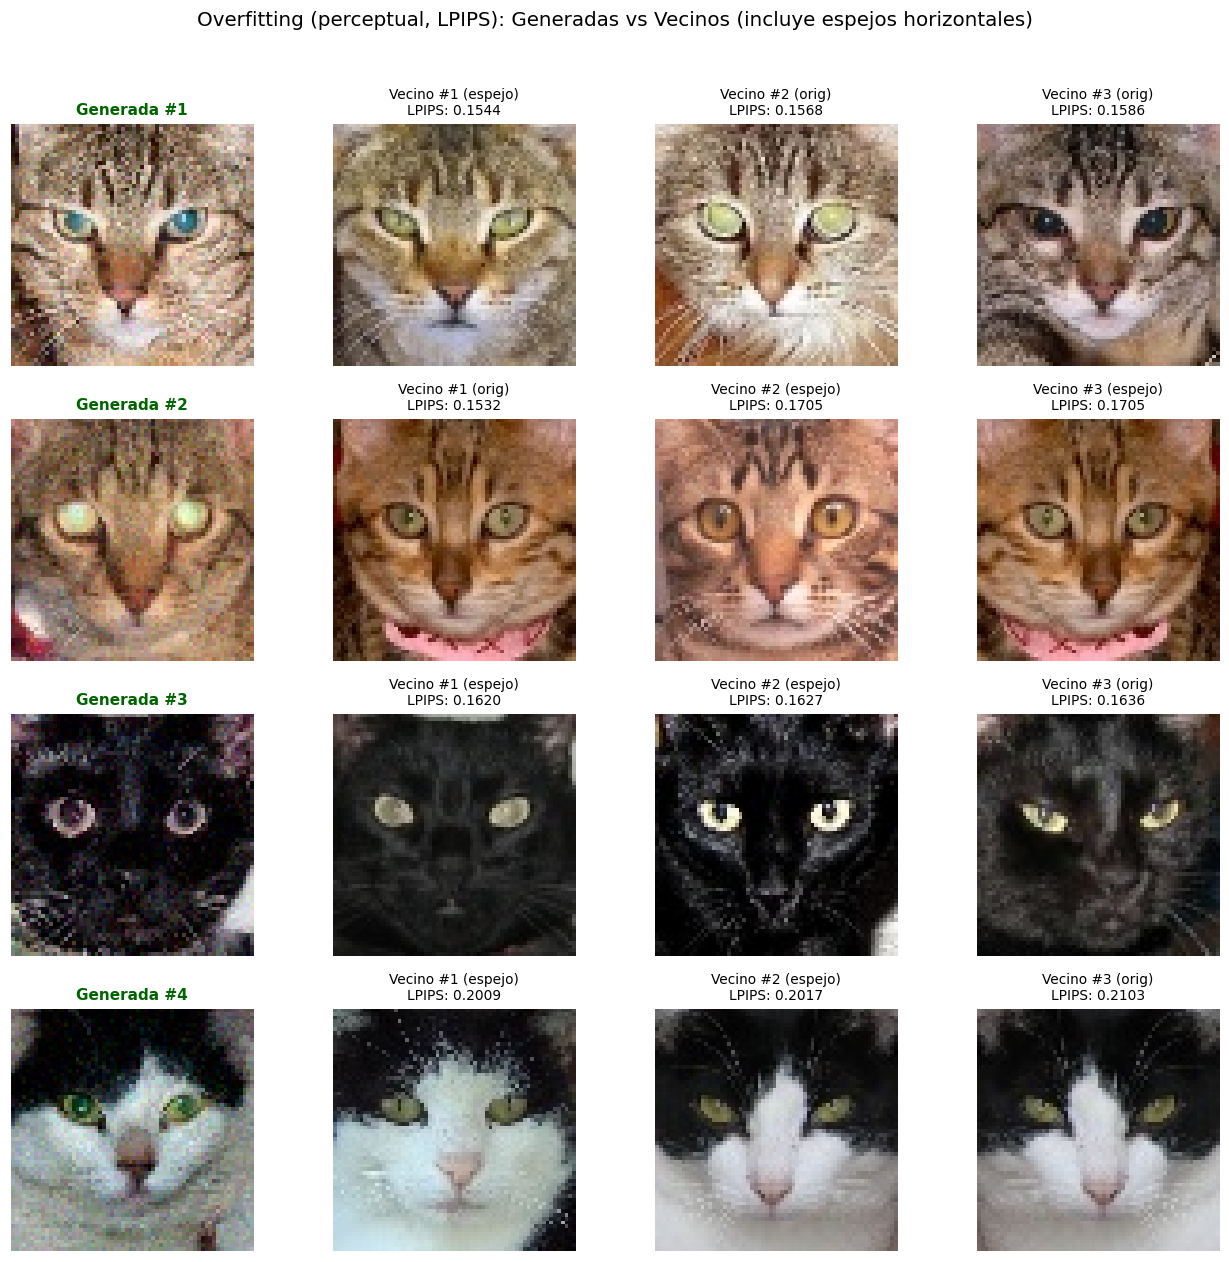

In [21]:
# --- 5b. Vecinos más cercanos en espacio PERCEPTUAL (LPIPS) ---
# MSE (celda anterior) detecta copias casi-exactas pero es sensible a corrimientos/color y se deja
# engañar por el fondo. LPIPS mide parecido PERCEPTUAL (distancia en features de una red preentrenada),
# robusto a esos corrimientos -> mejor para "¿a qué gato se parece de verdad?".
# Requiere el paquete `lpips`:  uv add lpips   (descarga pesos AlexNet la 1ra vez -> necesita internet).
# Reutiliza X_all (originales + espejos), samples_cpu, N_gen y denorm de la celda anterior.
try:
    import lpips
    _HAS_LPIPS = True
except ImportError:
    _HAS_LPIPS = False
    print("Falta el paquete 'lpips'. Instalalo con `uv add lpips` (o `pip install lpips`) y re-corré esta celda.")

if _HAS_LPIPS and DATA_DIR is not None:
    lpips_device = "cuda" if torch.cuda.is_available() else "cpu"
    lpips_fn = lpips.LPIPS(net="alex", verbose=False).to(lpips_device).eval()

    # LPIPS espera RGB en [-1, 1] (B,3,H,W) -> es EXACTAMENTE el rango de X_all y de las muestras,
    # así que NO se des-normaliza para la métrica (denorm es solo para mostrar).
    X_all_dev = X_all.to(lpips_device)
    N = X_dataset.shape[0]
    K_NEIGHBORS = 3
    CHUNK = 256  # procesar X_all de a bloques para no reventar la memoria

    fig, axes = plt.subplots(
        N_gen, K_NEIGHBORS + 1,
        figsize=(3.0 * (K_NEIGHBORS + 1), 2.8 * N_gen)
    )
    if N_gen == 1:
        axes = np.expand_dims(axes, axis=0)

    with torch.no_grad():
        for i in range(N_gen):
            gen = samples_cpu[i:i+1].to(lpips_device)          # (1,3,H,W) en [-1,1]
            dists = []
            for s in range(0, X_all_dev.shape[0], CHUNK):
                block = X_all_dev[s:s+CHUNK]
                gen_rep = gen.repeat(block.shape[0], 1, 1, 1)  # (b,3,H,W)
                d = lpips_fn(gen_rep, block)                   # (b,1,1,1)
                dists.append(d.flatten().cpu())
            lpips_d = torch.cat(dists).numpy()                 # (2N,)
            top_k = np.argsort(lpips_d)[:K_NEIGHBORS]

            axes[i, 0].imshow(denorm(samples_cpu[i:i+1])[0])
            axes[i, 0].set_title(f"Generada #{i+1}", fontsize=10, fontweight="bold", color="darkgreen")
            axes[i, 0].axis("off")

            for k_idx, idx in enumerate(top_k):
                etiqueta = "espejo" if idx >= N else "orig"    # idx >= N -> vino de X_flip
                axes[i, k_idx + 1].imshow(denorm(X_all[idx:idx+1])[0])
                axes[i, k_idx + 1].set_title(f"Vecino #{k_idx+1} ({etiqueta})\nLPIPS: {lpips_d[idx]:.4f}", fontsize=9)
                axes[i, k_idx + 1].axis("off")

    fig.suptitle("Overfitting (perceptual, LPIPS): Generadas vs Vecinos (incluye espejos horizontales)", fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()

## Cierre y Resumen

- **Carga de Checkpoint**: El notebook se integra con las salidas producidas por `config/cats_vp.yaml` (`ScoreUNet` + `VP-SDE`).
- **Generación desde ruido**: Se utilizó `generate_from_checkpoint` para reconstruir imágenes a partir de prior gaussiano $x_T \sim \mathcal{N}(0, I)$.
- **Estudio de Ablación (Eje 2)**: Se compararon los samplers `euler`, `pf_ode`, `heun` y `pc` bajo la misma semilla, comprobando que cambiar la estrategia de muestreo no requiere modificar ni reentrenar la red de score.
- **Análisis de Overfitting / Generalización**: La búsqueda de vecinos más cercanos (Nearest Neighbors) permite constatar empíricamente el nivel de memorización vs aprendizaje de la variedad subyacente.